# Notebook 4: Bike Sharing Demand
**Fuente:** https://www.kaggle.com/competitions/bike-sharing-demand/data

Dataset de demanda de alquiler de bicicletas por hora en Washington D.C. Contiene información meteorológica y temporal para predecir el número total de bicicletas alquiladas.

## Introducción
El objetivo es predecir la demanda de alquiler de bicicletas (`count`) en función de variables temporales (hora, día, mes, año, temporada) y meteorológicas (temperatura, humedad, velocidad del viento, condición climática). Es un problema de **regresión supervisada**.

## Carga del Dataset

In [2]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_PATH   = '/content/drive/MyDrive/datasets/sampleSubmission.csv'
    EXPORT_PATH = '/content/drive/MyDrive/datasets/bike_sharing/output/'
else:
    DATA_PATH   = 'train.csv'
    EXPORT_PATH = './bike_sharing_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: (6493, 2)


,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0


## Identificación del Tipo de Problema

In [3]:
TARGET = 'count'
print(f'Variable objetivo: {TARGET}')
print(f'Tipo: {df[TARGET].dtype}')
print(f'Rango: [{df[TARGET].min()}, {df[TARGET].max()}]')
print('\n→ Tipo de problema: REGRESIÓN (predicción de demanda horaria de bicicletas)')

Variable objetivo: count
Tipo: int64
Rango: [0, 0]

→ Tipo de problema: REGRESIÓN (predicción de demanda horaria de bicicletas)


## Análisis Exploratorio (EDA)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Info del dataset:')
df.info()
print('\nEstadísticas descriptivas:')
display(df.describe())

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   datetime  6493 non-null   object
 1   count     6493 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 101.6+ KB

Estadísticas descriptivas:


,count
count,6493.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


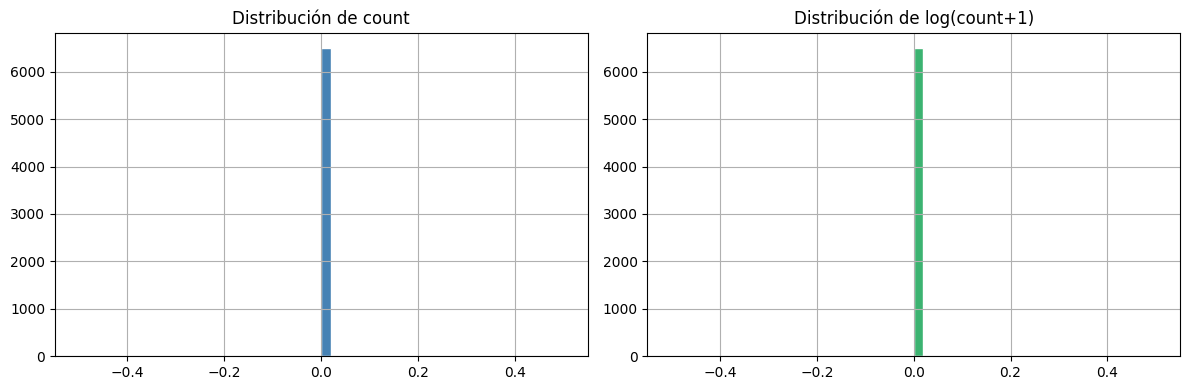

In [5]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df[TARGET].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de count')
np.log1p(df[TARGET]).hist(bins=50, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribución de log(count+1)')
plt.tight_layout()
plt.show()

In [7]:
# Demanda por hora del día
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year



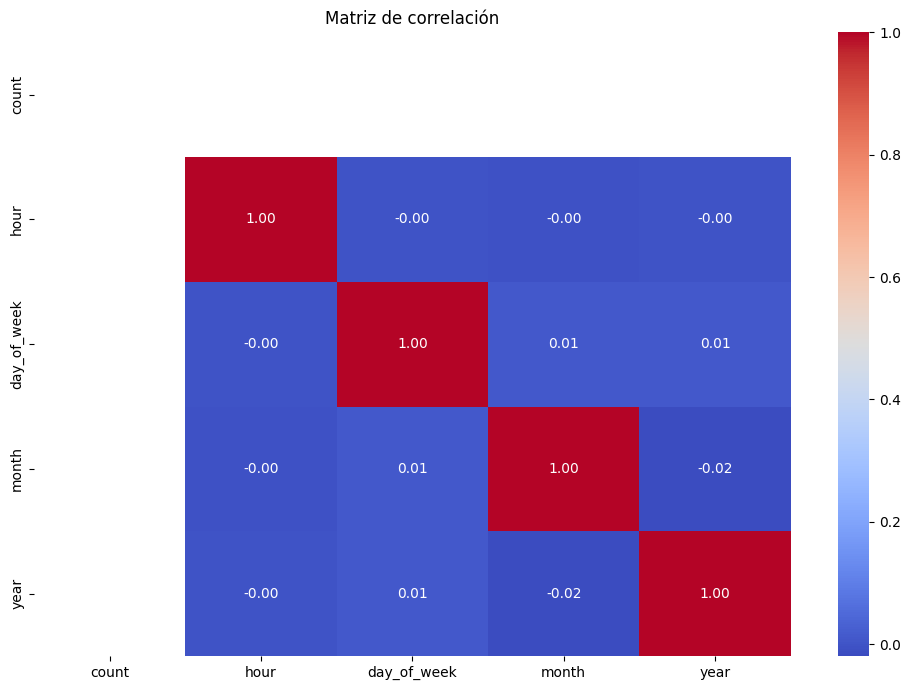

In [8]:
# Correlaciones
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## Limpieza y Preparación

In [9]:
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'Duplicados: {df.duplicated().sum()}')
df = df.drop_duplicates()

# Eliminar columnas de conteos intermedios (casual, registered)
cols_to_drop = ['casual', 'registered', 'datetime']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Tratamiento de outliers en target con IQR
Q1, Q3 = df[TARGET].quantile(0.25), df[TARGET].quantile(0.75)
IQR = Q3 - Q1
before = df.shape[0]
df = df[(df[TARGET] >= Q1 - 1.5*IQR) & (df[TARGET] <= Q3 + 1.5*IQR)]
print(f'Outliers eliminados: {before - df.shape[0]}')
print(f'Shape final: {df.shape}')

Valores nulos: 0
Duplicados: 0
Outliers eliminados: 0
Shape final: (6493, 5)


##  Transformación y Preprocesamiento

In [11]:
from sklearn.preprocessing import StandardScaler

df_processed = df.copy()

# Transformación logarítmica al target para reducir sesgo
df_processed['log_count'] = np.log1p(df_processed[TARGET])
TARGET_TRANSFORMED = 'log_count'
df_processed = df_processed.drop(columns=[TARGET])

# Variables categóricas a convertir en dummies
cat_cols = ['season', 'weather', 'holiday', 'workingday']
cat_cols = [c for c in cat_cols if c in df_processed.columns]
print(f"Categorical columns found for one-hot encoding: {cat_cols}") # Added debug
df_processed = pd.get_dummies(df_processed, columns=cat_cols, drop_first=True)

# Escalar variables numéricas continuas
num_scale_cols = ['temp', 'atemp', 'humidity', 'windspeed']
num_scale_cols = [c for c in num_scale_cols if c in df_processed.columns]
print(f"Numeric columns found for scaling: {num_scale_cols}") # Added debug

if num_scale_cols: # Added conditional check
    scaler = StandardScaler()
    df_processed[num_scale_cols] = scaler.fit_transform(df_processed[num_scale_cols])
else:
    print("Warning: No numeric columns found for scaling. StandardScaler was not applied.") # Added warning

print(f'Shape preprocesado: {df_processed.shape}')
df_processed.head()

Categorical columns found for one-hot encoding: []
Numeric columns found for scaling: []
Shape preprocesado: (6493, 5)


,hour,day_of_week,month,year,log_count
0,0,3,1,2011,0.0
1,1,3,1,2011,0.0
2,2,3,1,2011,0.0
3,3,3,1,2011,0.0
4,4,3,1,2011,0.0


##  División Train/Test (80/20)

In [12]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET_TRANSFORMED])
y = df_processed[TARGET_TRANSFORMED]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

train_df = X_train.copy(); train_df[TARGET_TRANSFORMED] = y_train.values
test_df  = X_test.copy();  test_df[TARGET_TRANSFORMED]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')

Train: (5194, 5)  |  Test: (1299, 5)


## Exportación de train.csv y test.csv

In [13]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado: {train_df.shape}')
print(f'✅ test.csv  guardado: {test_df.shape}')

✅ train.csv guardado: (5194, 5)
✅ test.csv  guardado: (1299, 5)
